# Task 1: Order Flow Imbalances (OFI)

**Author:** Patrick Mekanna 
**Date:** 2025-05-02  
**Reference Paper:** *Cross-Impact of Order Flow Imbalance in Equity Markets* (Cont et al.)

---

### Project Overview

This project implements a suite of Order Flow Imbalance (OFI) features, aligned with the methodology in Cont et al. (2023), and extends it with resampling, PCA-based Integrated OFI, and cross-asset impact modeling using LASSO regression.

The analysis is structured into the following components:

1. **Best-Level OFI**  
2. **Multi-Level OFI**  
3. **Integrated OFI**  
4. **Cross-Asset OFI** 

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [4]:
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "first_25000_rows.csv")
df = pd.read_csv(desktop_path)

print(df.head())

                          ts_recv                        ts_event  rtype  \
0  2024-10-21T11:54:29.221230963Z  2024-10-21T11:54:29.221064336Z     10   
1  2024-10-21T11:54:29.223936626Z  2024-10-21T11:54:29.223769812Z     10   
2  2024-10-21T11:54:29.225196809Z  2024-10-21T11:54:29.225030400Z     10   
3  2024-10-21T11:54:29.712600612Z  2024-10-21T11:54:29.712434212Z     10   
4  2024-10-21T11:54:29.764839221Z  2024-10-21T11:54:29.764673165Z     10   

   publisher_id  instrument_id action side  depth   price  size  ...  \
0             2             38      C    B      1  233.62     2  ...   
1             2             38      A    B      0  233.67     2  ...   
2             2             38      A    B      0  233.67     3  ...   
3             2             38      A    B      2  233.52   200  ...   
4             2             38      C    B      2  233.52   200  ...   

   ask_sz_08  bid_ct_08  ask_ct_08  bid_px_09  ask_px_09  bid_sz_09  \
0        155          1          7     

In [5]:
print(df.columns)

Index(['ts_recv', 'ts_event', 'rtype', 'publisher_id', 'instrument_id',
       'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta',
       'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00',
       'bid_ct_00', 'ask_ct_00', 'bid_px_01', 'ask_px_01', 'bid_sz_01',
       'ask_sz_01', 'bid_ct_01', 'ask_ct_01', 'bid_px_02', 'ask_px_02',
       'bid_sz_02', 'ask_sz_02', 'bid_ct_02', 'ask_ct_02', 'bid_px_03',
       'ask_px_03', 'bid_sz_03', 'ask_sz_03', 'bid_ct_03', 'ask_ct_03',
       'bid_px_04', 'ask_px_04', 'bid_sz_04', 'ask_sz_04', 'bid_ct_04',
       'ask_ct_04', 'bid_px_05', 'ask_px_05', 'bid_sz_05', 'ask_sz_05',
       'bid_ct_05', 'ask_ct_05', 'bid_px_06', 'ask_px_06', 'bid_sz_06',
       'ask_sz_06', 'bid_ct_06', 'ask_ct_06', 'bid_px_07', 'ask_px_07',
       'bid_sz_07', 'ask_sz_07', 'bid_ct_07', 'ask_ct_07', 'bid_px_08',
       'ask_px_08', 'bid_sz_08', 'ask_sz_08', 'bid_ct_08', 'ask_ct_08',
       'bid_px_09', 'ask_px_09', 'bid_sz_09', 'ask_sz_09', 'bi

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ts_recv        5000 non-null   object 
 1   ts_event       5000 non-null   object 
 2   rtype          5000 non-null   int64  
 3   publisher_id   5000 non-null   int64  
 4   instrument_id  5000 non-null   int64  
 5   action         5000 non-null   object 
 6   side           5000 non-null   object 
 7   depth          5000 non-null   int64  
 8   price          5000 non-null   float64
 9   size           5000 non-null   int64  
 10  flags          5000 non-null   int64  
 11  ts_in_delta    5000 non-null   int64  
 12  sequence       5000 non-null   int64  
 13  bid_px_00      5000 non-null   float64
 14  ask_px_00      5000 non-null   float64
 15  bid_sz_00      5000 non-null   int64  
 16  ask_sz_00      5000 non-null   int64  
 17  bid_ct_00      5000 non-null   int64  
 18  ask_ct_0

---
## Best-Level OFI

In [7]:
def compute_best_level_ofi(df):
    df = df.sort_values(by='ts_event').reset_index(drop=True)
    
    # Extract best bid/ask prices and sizes
    bid_px = df['bid_px_00'].values
    ask_px = df['ask_px_00'].values
    bid_sz = df['bid_sz_00'].values
    ask_sz = df['ask_sz_00'].values

    ofi = []

    for i in range(1, len(df)):
        # Bid side
        if bid_px[i] > bid_px[i-1]:
            bid_contrib = bid_sz[i]
        elif bid_px[i] == bid_px[i-1]:
            bid_contrib = bid_sz[i] - bid_sz[i-1]
        else:
            bid_contrib = -bid_sz[i-1]
        
        # Ask side
        if ask_px[i] > ask_px[i-1]:
            ask_contrib = -ask_sz[i-1]
        elif ask_px[i] == ask_px[i-1]:
            ask_contrib = ask_sz[i-1] - ask_sz[i]
        else:
            ask_contrib = ask_sz[i]

        ofi.append(bid_contrib + ask_contrib)

    ofi = [np.nan] + ofi
    df['ofi_best_level'] = ofi

    return df


In [8]:
df_with_ofi = compute_best_level_ofi(df)
print(df_with_ofi[['ts_event', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00', 'ofi_best_level']].head(10))

                         ts_event  bid_px_00  ask_px_00  bid_sz_00  ask_sz_00  \
0  2024-10-21T11:54:29.221064336Z     233.67     233.74        139        200   
1  2024-10-21T11:54:29.223769812Z     233.67     233.74        141        200   
2  2024-10-21T11:54:29.225030400Z     233.67     233.74        144        200   
3  2024-10-21T11:54:29.712434212Z     233.67     233.74        144        200   
4  2024-10-21T11:54:29.764673165Z     233.67     233.74        144        200   
5  2024-10-21T11:54:29.764685027Z     233.67     233.74        144        200   
6  2024-10-21T11:54:36.289427977Z     233.67     233.74        144        200   
7  2024-10-21T11:54:37.990793976Z     233.67     233.73        144        200   
8  2024-10-21T11:54:39.124291588Z     233.67     233.75        144          1   
9  2024-10-21T11:54:39.134140341Z     233.67     233.74        144        200   

   ofi_best_level  
0             NaN  
1             2.0  
2             3.0  
3             0.0  
4       

### Let’s now visualize the Best-Level OFI alongside the mid-price to understand how OFI relates to short-term price dynamics

In [9]:
def plot_ofi_vs_price(df, sample_size=1000):
    # Use mid-price (best bid + best ask) / 2
    df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2

    # Downsample for visibility (or increase sample_size for more data)
    sample_df = df[['ts_event', 'mid_price', 'ofi_best_level']].dropna().head(sample_size)

    # Convert timestamp if needed
    sample_df['ts_event'] = pd.to_datetime(sample_df['ts_event'])

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Mid-price plot
    ax1.set_xlabel("Timestamp")
    ax1.set_ylabel("Mid-Price", color='tab:blue')
    ax1.plot(sample_df['ts_event'], sample_df['mid_price'], label='Mid Price', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # OFI plot
    ax2 = ax1.twinx()
    ax2.set_ylabel("OFI (Best Level)", color='tab:red')
    ax2.plot(sample_df['ts_event'], sample_df['ofi_best_level'], label='Best-Level OFI', color='tab:red', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title("Best-Level OFI vs Mid-Price")
    fig.tight_layout()
    plt.grid(True)
    plt.show()


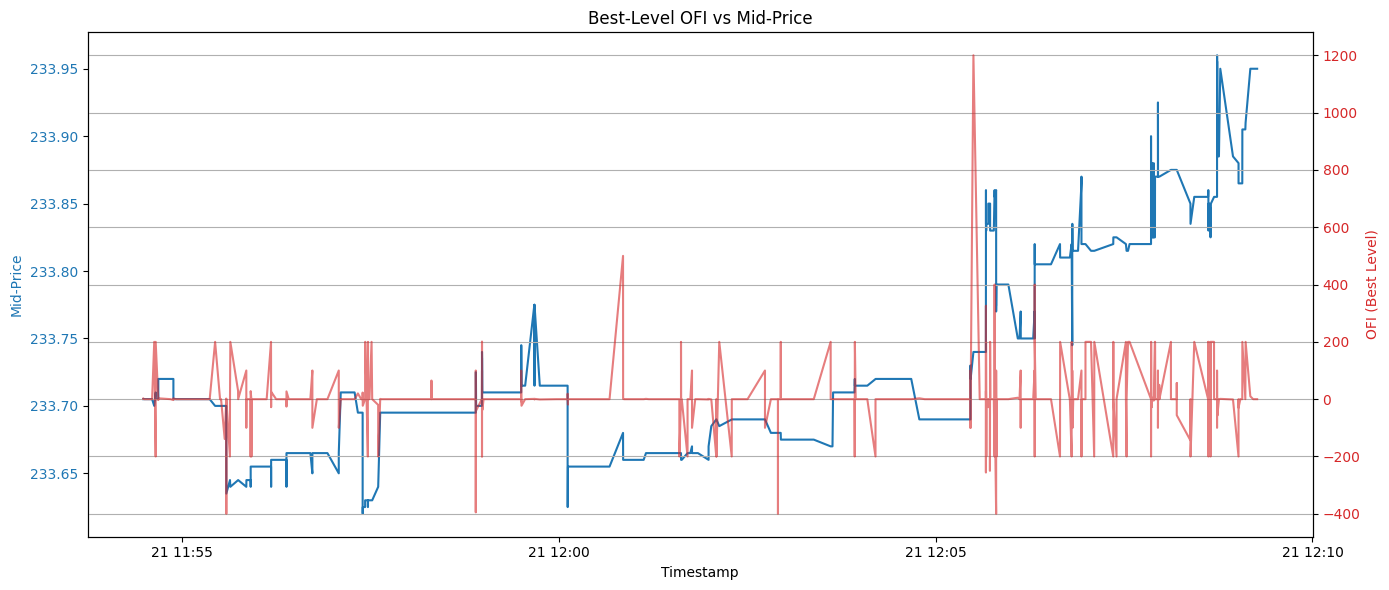

In [10]:
plot_ofi_vs_price(df_with_ofi)

---
## Multi-Level OFI

In [18]:
def compute_multi_level_ofi(df, levels=10):
    df = df.sort_values(by='ts_event').reset_index(drop=True)
    multi_ofi = pd.DataFrame(index=df.index)

    for lvl in range(levels):
        lvl_str = f"{lvl:02d}" 
        
        bid_px = df[f'bid_px_{lvl_str}'].values
        bid_sz = df[f'bid_sz_{lvl_str}'].values
        ask_px = df[f'ask_px_{lvl_str}'].values
        ask_sz = df[f'ask_sz_{lvl_str}'].values

        ofi = [np.nan]
        for i in range(1, len(df)):
            # Bid side
            if bid_px[i] > bid_px[i - 1]:
                bid_contrib = bid_sz[i]
            elif bid_px[i] == bid_px[i - 1]:
                bid_contrib = bid_sz[i] - bid_sz[i - 1]
            else:
                bid_contrib = -bid_sz[i - 1]

            # Ask side
            if ask_px[i] > ask_px[i - 1]:
                ask_contrib = -ask_sz[i - 1]
            elif ask_px[i] == ask_px[i - 1]:
                ask_contrib = ask_sz[i - 1] - ask_sz[i]
            else:
                ask_contrib = ask_sz[i]

            ofi.append(bid_contrib + ask_contrib)

        multi_ofi[f'ofi_lvl_{lvl}'] = ofi

    return pd.concat([df, multi_ofi], axis=1)

In [19]:
df_with_multi_ofi = compute_multi_level_ofi(df)
print(df_with_multi_ofi[[f'ofi_lvl_{i}' for i in range(5)]].head(10))


   ofi_lvl_0  ofi_lvl_1  ofi_lvl_2  ofi_lvl_3  ofi_lvl_4
0        NaN        NaN        NaN        NaN        NaN
1        2.0        0.0        0.0        0.0        0.0
2        3.0        0.0        0.0        0.0        0.0
3        0.0        0.0      200.0        0.0        0.0
4        0.0        0.0     -200.0        0.0        0.0
5        0.0      400.0       10.0        0.0        0.0
6        0.0        0.0        0.0        0.0        0.0
7      200.0        0.0        0.0        0.0        0.0
8     -200.0       -1.0       -8.0     -150.0      -29.0
9      200.0        1.0        8.0      150.0       29.0



 ### Now, let's display a few OFI levels (0 through 4) over a selected time window

In [20]:
def plot_multi_level_ofi(df, levels_to_plot=[0, 1, 2, 3, 4], sample_size=1000):
    df['ts_event'] = pd.to_datetime(df['ts_event'])
    sample_df = df.head(sample_size)

    plt.figure(figsize=(14, 6))
    for lvl in levels_to_plot:
        plt.plot(sample_df['ts_event'], sample_df[f'ofi_lvl_{lvl}'], label=f'OFI Level {lvl}')

    plt.xlabel("Timestamp")
    plt.ylabel("OFI Value")
    plt.title("Multi-Level Order Flow Imbalance")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


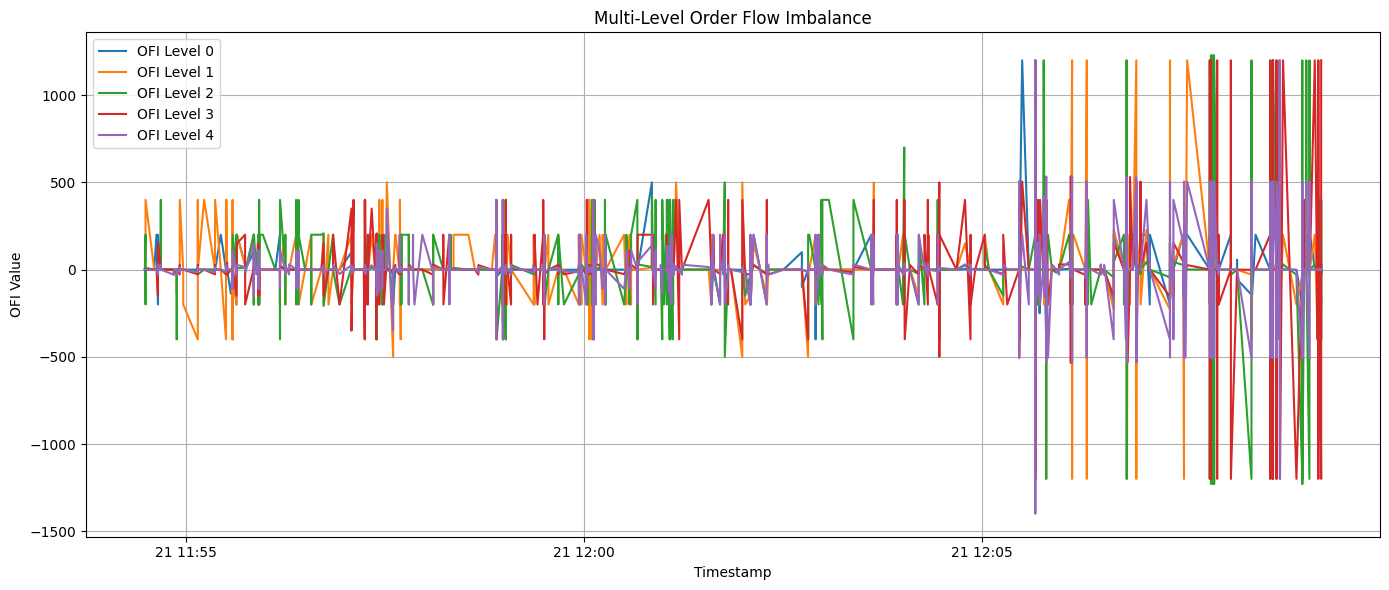

In [21]:
plot_multi_level_ofi(df_with_multi_ofi)


###  Quite hard to interpret but let's look at the depth of all orders, the “OFI fingerprint” at each time

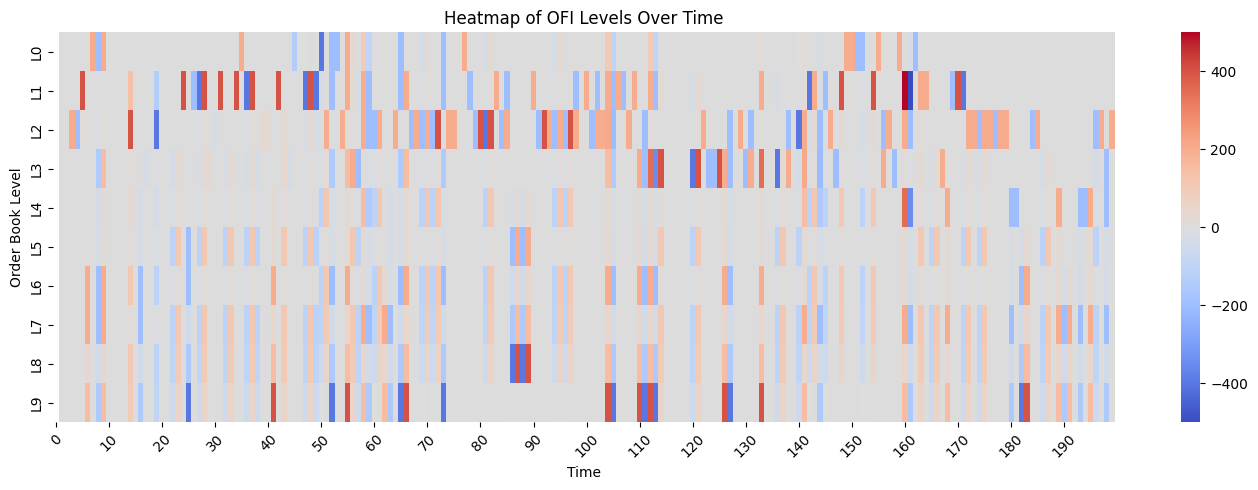

In [25]:

def plot_ofi_heatmap(df, levels=10, sample_size=200):
    df['ts_event'] = pd.to_datetime(df['ts_event'])
    sample_df = df.head(sample_size)
    
    ofi_matrix = sample_df[[f'ofi_lvl_{i}' for i in range(levels)]].T  # levels x time
    time_labels = sample_df['ts_event'].dt.strftime("%H:%M:%S").tolist()

    plt.figure(figsize=(14, 5))
    sns.heatmap(ofi_matrix, cmap="coolwarm", center=0, xticklabels=10, yticklabels=[f"L{i}" for i in range(levels)])
    plt.xticks(rotation=45)
    plt.title("Heatmap of OFI Levels Over Time")
    plt.xlabel("Time")
    plt.ylabel("Order Book Level")
    plt.tight_layout()
    plt.show()


plot_ofi_heatmap(df_with_multi_ofi)

---
## Integrated OFI

In [47]:

def compute_integrated_ofi(df, levels=10):
    ofi_cols = [f'ofi_lvl_{i}' for i in range(levels)]
    ofi_matrix = df[ofi_cols].dropna().copy()

    # Normalize each level (mean 0, std 1)
    scaler = StandardScaler()
    ofi_scaled = scaler.fit_transform(ofi_matrix)

    # PCA: preserve only 1st principal component
    pca = PCA(n_components=1)
    integrated_ofi = pca.fit_transform(ofi_scaled)

    # Normalize weights so they sum to 1 (L1 norm)
    pc1_weights = pca.components_[0]
    pc1_weights /= np.sum(np.abs(pc1_weights))

    df_result = df.copy()
    df_result.loc[ofi_matrix.index, 'ofi_integrated'] = integrated_ofi.flatten()

    return df_result, pc1_weights


In [48]:
df_with_integrated_ofi, weights = compute_integrated_ofi(df_with_multi_ofi)
print("PCA Weights:", weights)
print(df_with_integrated_ofi[['ts_event', 'ofi_integrated']].dropna().head())


PCA Weights: [0.07697806 0.08655126 0.08879016 0.11187617 0.11650695 0.11902528
 0.12140105 0.10238108 0.09054407 0.08594592]
                             ts_event  ofi_integrated
1 2024-10-21 11:54:29.223769812+00:00       -0.038518
2 2024-10-21 11:54:29.225030400+00:00       -0.035578
3 2024-10-21 11:54:29.712434212+00:00        0.152238
4 2024-10-21 11:54:29.764673165+00:00       -0.241034
5 2024-10-21 11:54:29.764685027+00:00        0.447948


### Let’s visualize the integrated OFI to see how it evolves over time and compare it with mid-price movements.

In [49]:
def plot_integrated_ofi(df, sample_size=1000):
    df = df.copy().dropna(subset=['ofi_integrated'])
    df['ts_event'] = pd.to_datetime(df['ts_event'])
    df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2

    sample_df = df.head(sample_size)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Mid-price plot
    ax1.set_xlabel("Timestamp")
    ax1.set_ylabel("Mid-Price", color='tab:blue')
    ax1.plot(sample_df['ts_event'], sample_df['mid_price'], label='Mid Price', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Integrated OFI plot
    ax2 = ax1.twinx()
    ax2.set_ylabel("Integrated OFI", color='tab:green')
    ax2.plot(sample_df['ts_event'], sample_df['ofi_integrated'], label='Integrated OFI', color='tab:green', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor='tab:green')

    plt.title("Integrated OFI vs Mid-Price")
    fig.tight_layout()
    plt.grid(True)
    plt.show()


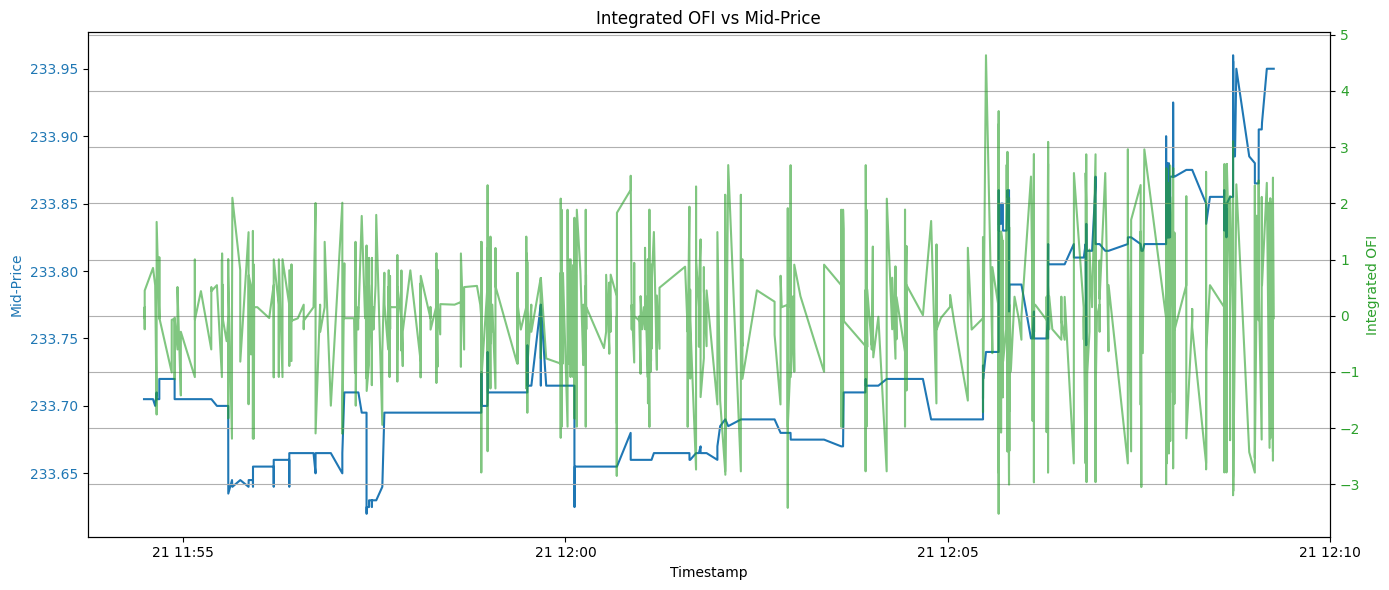

In [50]:
plot_integrated_ofi(df_with_integrated_ofi)


### Let’s look at how the first principal component weights the OFI across different levels to reveal where the most predictive pressure lies.

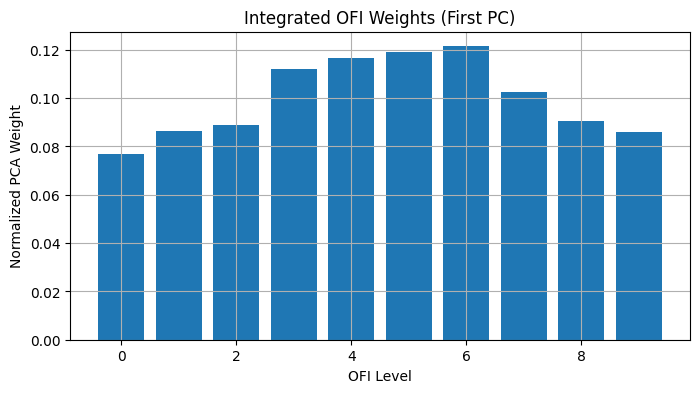

In [ ]:
def plot_pca_weights(weights):
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(weights)), weights)
    plt.xlabel("OFI Level")
    plt.ylabel("Normalized PCA Weight")
    plt.title("Integrated OFI Weights (First PC)")
    plt.grid(True)
    plt.show()

plot_pca_weights(weights)


---
# Cross-Asset OFI 

In [64]:
#  Integrated OFI (PCA from Multi-Level OFIs)
def compute_integrated_ofi(df, levels=10):
    ofi_cols = [f'ofi_lvl_{i}' for i in range(levels)]
    ofi_matrix = df[ofi_cols].dropna().copy()

    scaler = StandardScaler()
    ofi_scaled = scaler.fit_transform(ofi_matrix)

    pca = PCA(n_components=1)
    integrated_ofi = pca.fit_transform(ofi_scaled)

    pc1_weights = pca.components_[0]
    pc1_weights /= np.sum(np.abs(pc1_weights))

    df_result = df.copy()
    df_result.loc[ofi_matrix.index, 'ofi_integrated'] = integrated_ofi.flatten()

    return df_result, pc1_weights

def resample_symbol_data(df, symbol, interval='1S'):
    df = df[df['symbol'] == symbol].copy()
    df['ts_event'] = pd.to_datetime(df['ts_event'])
    df = df.set_index('ts_event')

    df['mid_price'] = (df['bid_px_00'] + df['ask_px_00']) / 2
    df['log_mid'] = np.log(df['mid_price'])

    log_returns = df['log_mid'].resample(interval).last().diff().rename(f'{symbol}_return')
    ofi = df['ofi_integrated'].resample(interval).sum().rename(f'{symbol}_ofi')

    return pd.concat([log_returns, ofi], axis=1)

# Merge all symbols into a single cross-asset dataset
def build_cross_asset_dataset(df, interval='1S'):
    symbols = df['symbol'].unique()
    resampled = [resample_symbol_data(df, sym, interval) for sym in symbols]
    combined = pd.concat(resampled, axis=1).dropna()
    return combined

# Run LASSO for each asset
def run_cross_asset_lasso(df_cross):
    symbols = list(set(col.split('_')[0] for col in df_cross.columns if '_ofi' in col))
    results = {}

    for sym in symbols:
        y = df_cross[f'{sym}_return']
        X = df_cross[[col for col in df_cross.columns if '_ofi' in col and not col.startswith(sym)]]

        model = LassoCV(cv=5, random_state=0)
        model.fit(X, y)

        results[sym] = {
            'lasso_model': model,
            'coefficients': pd.Series(model.coef_, index=X.columns),
            'intercept': model.intercept_,
            'score': model.score(X, y)
        }

        print(f"\n[{sym}] LASSO R²: {model.score(X, y):.4f}")
        print(results[sym]['coefficients'][results[sym]['coefficients'] != 0])

    return results


In [ ]:
df_with_integrated, weights = compute_integrated_ofi(df_with_multi_ofi)
df_cross = build_cross_asset_dataset(df_with_integrated)
results = run_cross_asset_lasso(df_cross)



[AAPL] LASSO R²: 0.0548
AAPL_ofi    0.000009
dtype: float64


/var/folders/fd/xpg236695cn5cp5bztdhzf0c0000gn/T/ipykernel_94801/367501300.py:29: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  log_returns = df['log_mid'].resample(interval).last().diff().rename(f'{symbol}_return')
/var/folders/fd/xpg236695cn5cp5bztdhzf0c0000gn/T/ipykernel_94801/367501300.py:30: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  ofi = df['ofi_integrated'].resample(interval).sum().rename(f'{symbol}_ofi')


NOTE: This dataset contains only one symbol (AAPL).
As a result, the cross-asset feature matrix `X` ends up empty 
when excluding the target asset's own OFI. To make the LASSO run in this single-asset case, we replace the feature selection line below:

#### X = df_cross[[col for col in df_cross.columns if '_ofi' in col and not col.startswith(sym)]] with this fallback that uses the asset’s own OFI:
#### X = df_cross[[f'{sym}_ofi']]  # Single-asset fallback: self-impact only
